## Morphological property characterision 
* **Classification**: Introduction demo
* **Primary objective**: Grain structure analysis of MCGS2D: neighbourhood analysis
* **Objective 2**: Learn to port temporal grain structure dataset to GS Analysis module	
* **Objective 3**: Create neighbourhood dictionaries across all temporal slices	
* **Objective 4**: Get temporal neighbourhood count distributions
* **Metadata**: Author: Dr. Sunil Anandatheertha. Created: 11-12-2025

## Imports, MCGS2D simulation, grain detection
This section sets up the necessary Python libraries and initializes the Monte Carlo Grain Simulator (MCGS2D) for polycrystalline microstructure simulation. The workflow includes:
- Importing required modules: `mcgs` for grain growth simulation, `gsan2d` for grain structure analysis, and visualization libraries
- Creating an MCGS instance with specified input parameters from the dashboard configuration file
- Running the Monte Carlo simulation to generate temporal grain evolution
- Detecting grains in the simulated microstructure for subsequent morphological analysis

In [24]:
from upxo.ggrowth.mcgs import mcgs
from upxo.analysis.analysis2d import gsan2d
import seaborn as sns
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pxt = mcgs(input_dashboard='C:\\Development\\UPXO\\upxo_library\\src\\upxo\\interfaces\\user_inputs\\input_dashboard_profiling_alg202a.xls')
pxt.simulate()
pxt.detect_grains()

C:\Development\UPXO\upxo_library\src\upxo\interfaces\user_inputs
C:\Development\UPXO\upxo_library\src\upxo\interfaces\user_inputs\input_dashboard_profiling_alg202a.xls
Algo_hops details
(('200.0', 100),)
[False]





 Initiating Monte-Carlo simulation
     xmin, xmax, xinc: 0.0, 100.0, 1.0
     ymin, ymax, yinc: 0.0, 100.0, 1.0
     zmin, zmax, zinc: 0.0, 1000.0, 1.0
     No. of states: 5
     Dimensionality: 2
     Algorithm: 200.0 





-----------------------
[1. 1. 1.]
[1. 1. 1.]
[1. 1. 1.]
-----------------------
########################################
200.0
########################################
Using ALG-200: SA's SL NL-1 TP1 C2 unweighted Q-Pott's model:
|--------------- MC SIM RUN IN PROGRESS on: ALG200---------------|
GS temporal slice 0 stored
 ..............................
GS temporal slice 1 stored
 ..............................
GS temporal slice 2 stored
 ..............................
GS temporal slice 3 stored
 ..............................
GS temporal slice 4 sto

## Port MCGS2d PXTAL into GS Analysis instance

This section bridges the grain growth simulation output to the grain structure analysis framework. The `gsan2d.from_gsstack_temporal()` method ingests the temporal grain stack from the MCGS2D simulation (`pxt`) and configures which morphological properties to compute:

- **Input**: Temporal grain structure data from the Monte Carlo simulation
- **Configuration**: Selective property computation flags control which morphological metrics are calculated (aspect ratio, solidity, eccentricity, Euler number, Hu moments, and grain coordinates are enabled)
- **Output**: A `gsan2d` analysis object containing the complete temporal grain stack with grain IDs and coordinates, ready for property extraction and neighbourhood analysis

This approach allows efficient memory usage by computing only required properties rather than the full morphological characterization suite.

In [25]:
gsan = gsan2d.from_gsstack_temporal(pxt, detect_grains=False, gsids=[], ispxtal=True, prechar=False, 
                                    npixels=False, npixels_gb=False, gb_length_px=False,
                                    eq_diameter=False, feret_diameter=False,
                                    perimeter=False, perimeter_crofton=False, aspect_ratio=True,
                                    compactness=False, solidity=True, morph_ori=False,
                                    circularity=False, eccentricity=True,
                                    euler_number=True, moments_hu=True,
                                    char_gb=False, get_grain_coords=True)
for gsid in gsan.gsstack.keys():
    gsan.gsstack[gsid].find_neigh()

 Characterizing grain structure slice 0 
Extracting requested GS props across all available states
--------State value: 5 of 5
----------------------------------------
 Characterizing grain structure slice 1 
Extracting requested GS props across all available states
--------State value: 5 of 5
----------------------------------------
 Characterizing grain structure slice 2 
Extracting requested GS props across all available states
--------State value: 5 of 5
----------------------------------------
 Characterizing grain structure slice 3 
Extracting requested GS props across all available states
--------State value: 5 of 5
----------------------------------------
 Characterizing grain structure slice 4 
Extracting requested GS props across all available states
--------State value: 5 of 5
----------------------------------------
 Characterizing grain structure slice 5 
Extracting requested GS props across all available states
--------State value: 5 of 5
---------------------------------

### Extract properties
This cell executes the morphological property extraction routine on the temporal grain stack. The `extract_props()` method computes all morphological properties that were enabled during the `gsan2d` initialization (cell 4), including:

- **Aspect ratio**: Ratio of major to minor axis length of the fitted ellipse
- **Solidity**: Ratio of grain area to its convex hull area (measure of concavity)
- **Eccentricity**: Measure of elongation of the grain shape
- **Euler number**: Topological descriptor (number of objects minus number of holes)
- **Hu moments**: Set of seven moment invariants for shape characterization

The extracted properties are stored within each grain structure slice in the temporal stack (`gsstack`), making them available for subsequent analysis, filtering, and neighbourhood characterization. This step is essential before performing property-based grain selection or statistical analysis on the microstructure.

In [26]:
gsan.extract_props()

### Give a list of morpholohical propertties of interest
### Define morphological properties of interest

This section specifies the key morphological properties that will be analyzed for grain characterization and threshold-based filtering:

- **area**: The number of pixels or physical area occupied by each grain
- **aspect_ratio**: The ratio of the major axis to minor axis of the best-fit ellipse, indicating grain elongation
- **perimeter**: The boundary length of the grain in pixels
- **solidity**: The ratio of grain area to its convex hull area, measuring shape compactness and concavity

These properties will be extracted from the grain structure stack and used to identify and filter grains based on specified threshold bounds in the subsequent analysis sections.

In [27]:
pnames=['area', 'aspect_ratio', 'perimeter', 'solidity']

### Select a specific temporal slice of interest and extract the morphological properties

This section demonstrates the selection and property extraction workflow for a specific temporal slice from the grain structure evolution:

**Temporal Slice Selection:**
- `gsid = 5` selects the 6th temporal slice (0-indexed) from the Monte Carlo grain growth simulation stack
- Each temporal slice represents a snapshot of the microstructure at a specific Monte Carlo step
- The grain structure stack (`gsstack`) contains the complete temporal evolution of grain IDs and geometries

**Morphological Property Extraction:**
The `get_mprops()` method retrieves morphological properties for all grains in the selected temporal slice:
- **area**: Computed as the total number of pixels occupied by each grain region
- **aspect_ratio**: Calculated from the fitted ellipse as the ratio of major axis length to minor axis length (major_axis_length / minor_axis_length)
- **perimeter**: Estimated using a 4-connectivity contour approximation of the grain boundary
- **solidity**: Computed as the ratio of grain area to its convex hull area (area / convex_area), measuring the degree of boundary concavity

The `set_missing_mprop=True` parameter ensures that if any requested property was not computed during the initial `extract_props()` call (cell 6), it will be calculated on-demand and added to the grain structure data. The method returns a dictionary with property names as keys and numpy arrays of property values (one value per grain) as values.

In [28]:
gsid = 5
mprops = gsan.gsstack[gsid].get_mprops(pnames, set_missing_mprop=True) 
mprops.keys()

Extracting requested GS props across all available states
--------State value: 5 of 5
----------------------------------------


dict_keys(['area', 'aspect_ratio', 'perimeter', 'solidity'])

# Identifty specific greains based on property values bounds

This section demonstrates grain filtering techniques based on morphological property thresholds, enabling targeted analysis of grain subpopulations with specific characteristics:

**Property-Based Grain Selection:**
The `get_property_bounded_grains()` method identifies grains whose morphological properties fall within specified lower and upper bounds. This allows:
- **Selective grain analysis**: Isolate grains with extreme or typical property values
- **Outlier detection**: Identify abnormally small/large, elongated, or irregular grains
- **Neighborhood characterization**: Study how grains with specific properties influence their neighbors

**Threshold Configuration:**
- **Lower bounds only** (Section 1): Filter grains below minimum property thresholds to identify small, elongated, irregular, or porous grains
- **Upper bounds** (Section 2): Filter grains above maximum property thresholds to identify large, equiaxed, or highly compact grains
- **Combined bounds**: Specify both minimum and maximum values to select grains within a property range

**Analysis Workflow:**
1. Define property threshold dictionaries (`pvalue_thresholds`) with [min, max] bounds for each property
2. Extract grain IDs (`props_gids`) that satisfy the threshold criteria
3. Visualize the filtered grain populations on the microstructure
4. Extract and analyze morphological properties of neighboring grains to understand local microstructural correlations

This approach is particularly valuable for understanding property correlations, identifying processing defects, and characterizing grain boundary networks in heterogeneous microstructures.

### 1. Lets proceed only with lower bound

In [29]:
amin = 10
armin = 2.0
permin = 15
solmin = 0.8
min_values = {'area': amin, 'aspect_ratio': armin,
              'perimeter': permin, 'solidity': solmin}
pvalue_thresholds = {'area': [amin, None],
                     'aspect_ratio': [armin, None],
                     'perimeter': [permin, None],
                     'solidity': [solmin, None]}

props_gids = gsan.gsstack[gsid].get_property_bounded_grains(pnames=pnames, mprops=mprops, pvalue_thresholds=pvalue_thresholds)
props_gids.keys()

dict_keys(['area', 'aspect_ratio', 'perimeter', 'solidity'])

### 1.a. Lets view the corresponding grains

This visualization enables spatial analysis of grain subpopulations filtered by morphological property thresholds. The plots can reveal:

**Spatial Distribution Patterns:**
- **Clustering**: Grains with similar property values may cluster in specific regions, indicating local processing variations or thermal gradients
- **Random dispersion**: Uniformly distributed filtered grains suggest homogeneous microstructure evolution
- **Banding or layering**: Linear arrangements may indicate directional solidification or rolling texture effects

**Microstructural Anomalies:**
- **Small grains** (low area): May indicate nucleation sites, recrystallization zones, or incomplete grain growth
- **Elongated grains** (high aspect ratio): Could reveal preferred growth directions, anisotropic boundary mobility, or strain localization
- **Irregular boundaries** (low solidity): May highlight grain boundary pinning by second phases, pore formation, or concave growth instabilities
- **Small perimeter grains**: Often correspond to newly nucleated or isolated grains in the early growth stages

**Processing Defects Identification:**
- Abnormal grain clusters may indicate temperature inhomogeneities, compositional variations, or localized deformation
- Isolated outliers could represent measurement artifacts or grain boundary triple junction effects

**Neighborhood Effects:**
- Spatial correlation between filtered grains and their neighbors provides insight into grain-grain interactions
- Grain impingement zones and boundary curvature-driven growth can be identified

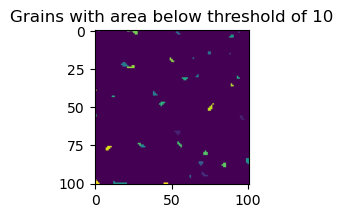

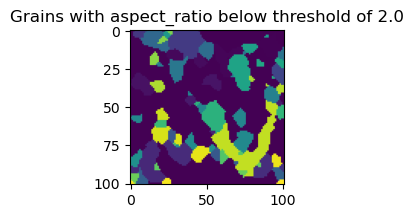

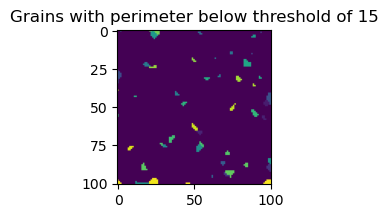

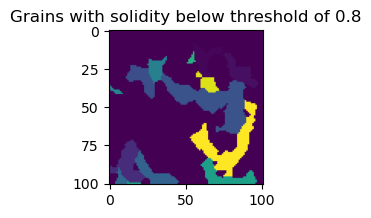

In [30]:
for pname in pnames:
    plt.figure(figsize=(2, 2))
    gsan.gsstack[gsid].plot_grains(props_gids[pname])
    plt.title(f'Grains with {pname} below threshold of {min_values[pname]}')
    plt.show()

### 1.b. View mprop distribution of gids obtained by thresholding the corresponding mprops

This section performs **neighborhood property analysis** by extracting morphological properties of grains that neighbor the thresholded grain populations. For each property-filtered grain set, the analysis computes the mean property values of all adjacent grains and visualizes their distribution using kernel density estimation (KDE).

**Why This Analysis Is Useful:**

- **Property correlation detection**: Reveals whether grains with extreme property values (e.g., high aspect ratio) tend to be surrounded by neighbors with similar or contrasting characteristics
- **Grain interaction mechanisms**: Identifies if abnormal grains influence their neighbors through boundary mobility effects, stress concentration, or preferential growth directions
- **Microstructural clustering**: Detects spatial heterogeneity where regions contain grains with correlated properties, indicating localized processing conditions or texture development
- **Boundary network characterization**: Understands how grain property distributions affect local boundary curvature, energy, and mobility

**How This Can Be Applied:**

1. **Quality control**: Identify regions where small/irregular grains cluster together, indicating incomplete recrystallization or abnormal grain growth
2. **Processing optimization**: Correlate grain property distributions with thermal history or deformation conditions to predict microstructure evolution
3. **Property prediction**: Use neighborhood property statistics to predict local mechanical behavior or failure initiation sites
4. **Growth kinetics analysis**: Determine if high aspect ratio grains are surrounded by similarly elongated neighbors (cooperative growth) or equiaxed grains (constrained growth)
5. **Defect analysis**: Examine if low solidity grains (porous/irregular boundaries) are isolated or form interconnected networks that could affect material integrity

The KDE plots provide smooth probability distributions that highlight whether neighbor properties differ significantly from the thresholded reference grains, enabling quantitative assessment of local property correlations.

### Lets view the thresholded grains again, @ pname = area

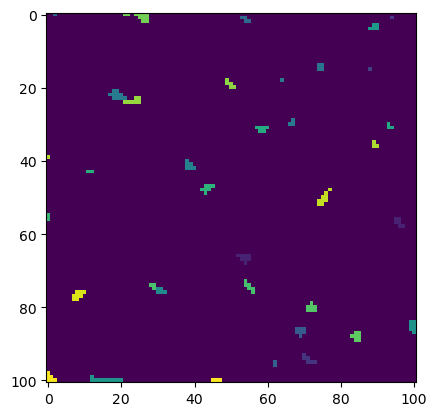

In [42]:
props_gids['area']
gsan.gsstack[gsid].plot_grains(props_gids['area'])

### lets view the O(1) grains of the above grains

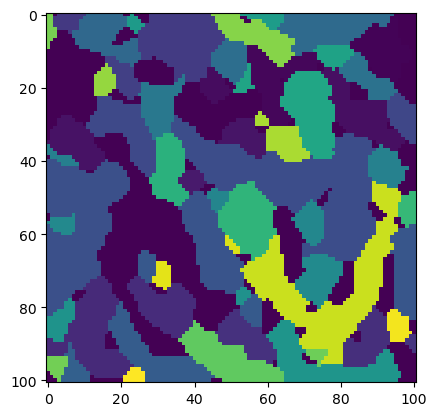

In [44]:
neighs = {fid: gsan.gsstack[gsid].neigh_gid[fid] for fid in props_gids['area']}
neighs_array = [fid for fid in np.hstack([neighs[fid] for fid in neighs.keys()]) 
                if fid not in props_gids['area']]
gsan.gsstack[gsid].plot_grains(neighs_array)

### lets plot the distribution of properties of these O(1) grains

As you can see, this can be become a powerful analysis pathway for comparison of multi-modal grain astrucrures by decomposing the grain structures based on neighbourhood data. Lets name this as `property-thresholded-neighbourhood-partitioning`

dict_keys(['gids', 'vals'])


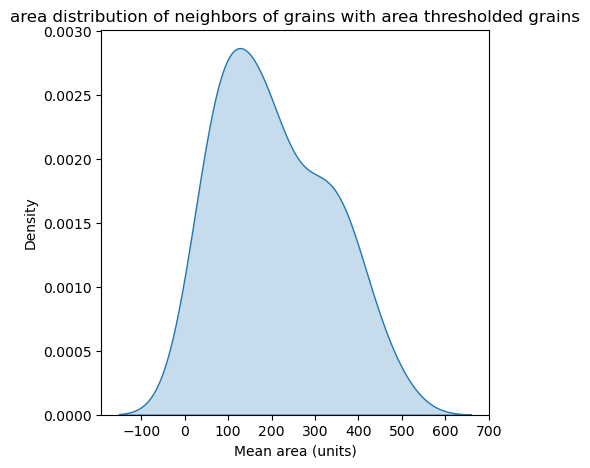

dict_keys(['gids', 'vals'])


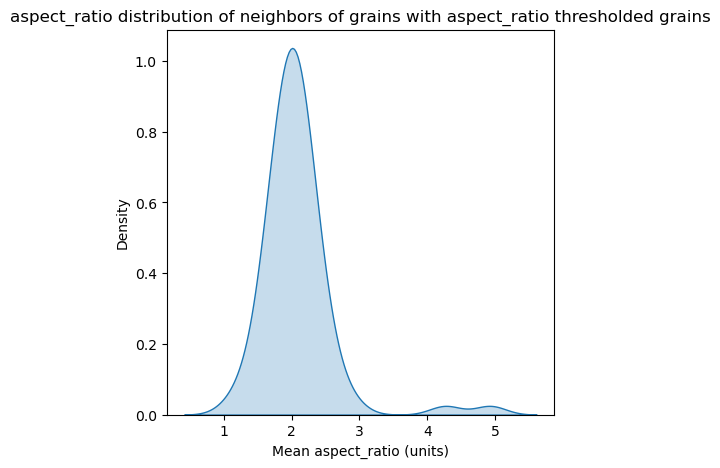

dict_keys(['gids', 'vals'])


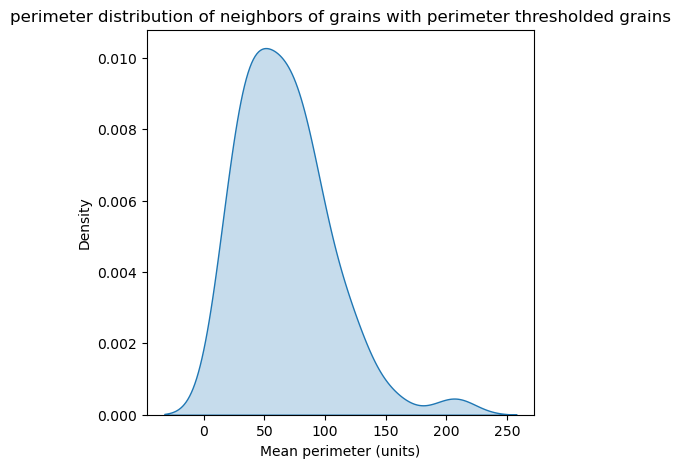

dict_keys(['gids', 'vals'])


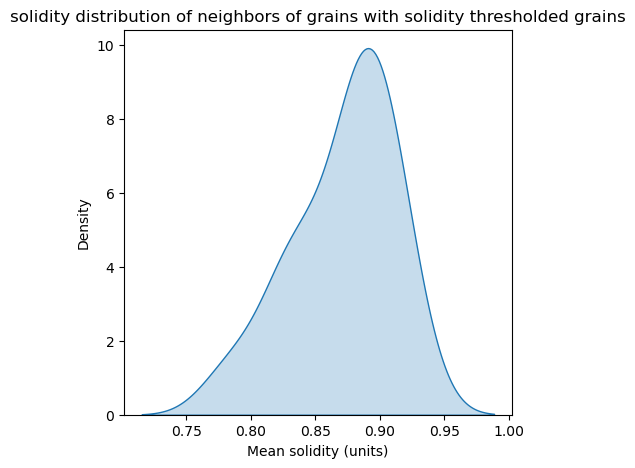

In [45]:
for ref_pname in pnames:
    mprops_neigh = gsan.gsstack[gsid].extract_neigh_props(props_gids[ref_pname], mprops[ref_pname])
    print(mprops_neigh.keys())
    mprops_neigh_metricked = []
    for fid, neigh_props in mprops_neigh['vals'].items():
        mprops_neigh_metricked.append(float(np.mean(neigh_props)))

    plt.figure(figsize=(5, 5))
    sns.kdeplot(mprops_neigh_metricked, cumulative=False, fill=True)
    plt.title(f'{ref_pname} distribution of neighbors of grains with {ref_pname} thresholded grains')
    plt.xlabel(f'Mean {ref_pname} (units)')
    plt.ylabel('Density')
    plt.show()

### 2. Lets proceed only with upper bound

Extracting requested GS props across all available states
--------State value: 5 of 5
----------------------------------------


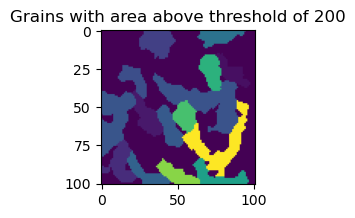

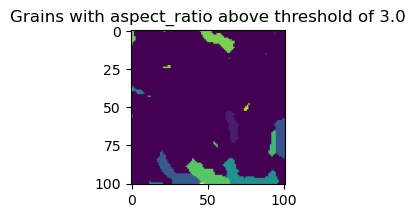

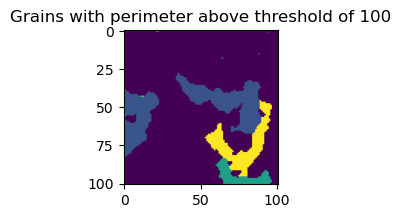

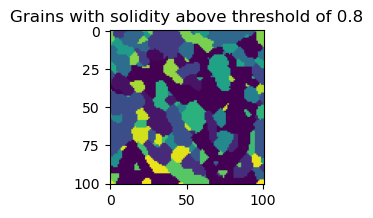

In [48]:
pnames=['area', 'aspect_ratio', 'perimeter', 'solidity']
mprops = gsan.gsstack[gsid].get_mprops(pnames, set_missing_mprop=True)
amin, amax = 0, 200
armin, armax = 0, 3.0
permin, permax = 0, 100
solmin, solmax = 0, 0.8
min_values = {'area': amin, 'aspect_ratio': armin,
              'perimeter': permin, 'solidity': solmin}
max_values = {'area': amax, 'aspect_ratio': armax,
              'perimeter': permax, 'solidity': solmax}
pvalue_thresholds = {'area': [amin, amax],
                     'aspect_ratio': [armin, armax],
                     'perimeter': [permin, permax],
                     'solidity': [solmin, solmax]}
props_gids = gsan.gsstack[gsid].get_property_bounded_grains(pnames=pnames, mprops=mprops, pvalue_thresholds=pvalue_thresholds)

for pname in pnames:
    plt.figure(figsize=(2,2))
    gsan.gsstack[gsid].plot_grains(props_gids[pname])
    plt.title(f'Grains with {pname} above threshold of {max_values[pname]}')
    plt.show()

dict_keys(['gids', 'vals'])


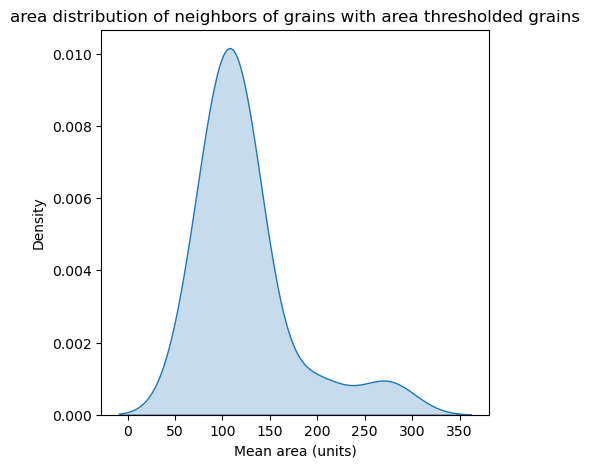

dict_keys(['gids', 'vals'])


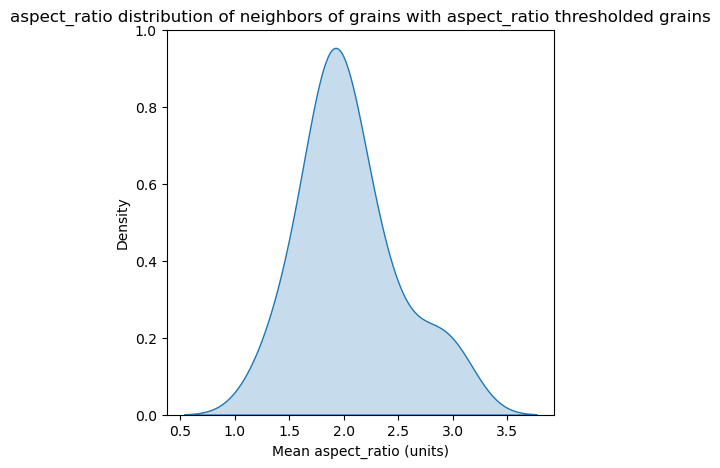

dict_keys(['gids', 'vals'])


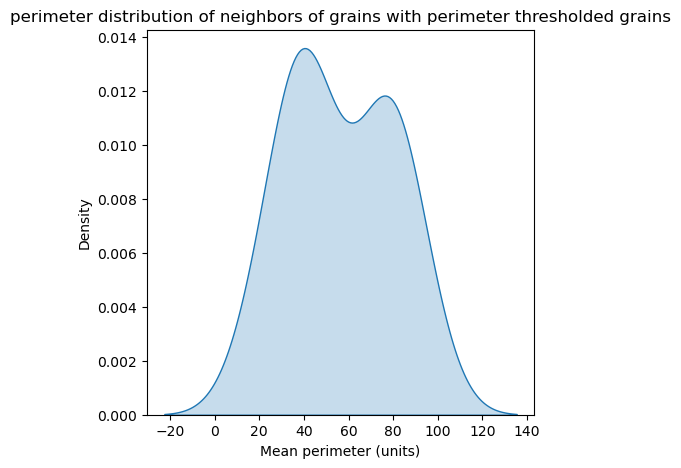

dict_keys(['gids', 'vals'])


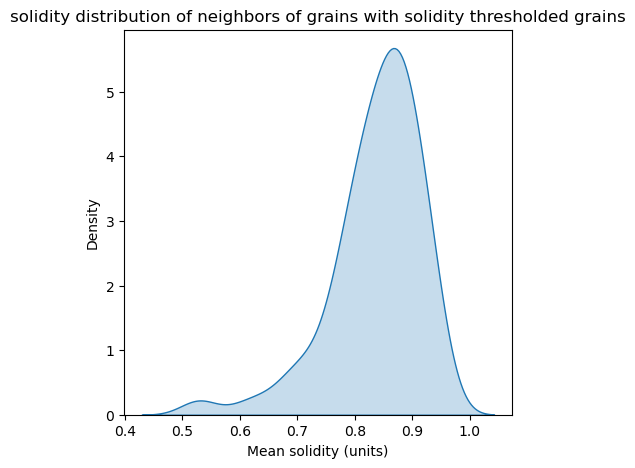

In [47]:
for ref_pname in pnames:
    mprops_neigh = gsan.gsstack[gsid].extract_neigh_props(props_gids[ref_pname], mprops[ref_pname])
    print(mprops_neigh.keys())
    mprops_neigh_metricked = []
    for fid, neigh_props in mprops_neigh['vals'].items():
        mprops_neigh_metricked.append(float(np.mean(neigh_props)))

    plt.figure(figsize=(5, 5))
    sns.kdeplot(mprops_neigh_metricked, cumulative=False, fill=True)
    plt.title(f'{ref_pname} distribution of neighbors of grains with {ref_pname} thresholded grains')
    plt.xlabel(f'Mean {ref_pname} (units)')
    plt.ylabel('Density')
    plt.show()